<a href="https://colab.research.google.com/github/nehnamehranmk638-dev/multilingual-rag-research/blob/nehna/notebooks/ml_07_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Malayalam Phase 1 — Step 7: Summary

Mirrors English `07_summary.ipynb`.

**What this notebook does:**
1. Loads all Malayalam results (BM25, Dense, Hybrid, Generation, Faithfulness)
2. Computes MRR for all three retrieval methods
3. Generates `master_summary_ml.csv`
4. Generates comparison charts
5. Writes `notes/summary_ml.md`
6. Pushes everything to GitHub

## 1. GitHub setup

In [ ]:
from google.colab import userdata

token = userdata.get("GITHUB_TOKEN")

print("Token loaded:", token is not None)

Token loaded: True


In [ ]:
import os

os.environ["GITHUB_TOKEN"] = token

!git clone https://$GITHUB_TOKEN@github.com/nehnamehranmk638-dev/multilingual-rag-research.git

Cloning into 'multilingual-rag-research'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (153/153), done.
remote: Total 180 (delta 76), reused 112 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (180/180), 968.09 KiB | 7.01 MiB/s, done.
Resolving deltas: 100% (76/76), done.


In [ ]:
%cd /content/multilingual-rag-research

/content/multilingual-rag-research


In [ ]:
import subprocess

username = "nehnamehrankmk638-dev"

credential = f"""protocol=https
host=github.com
username={username}
password={token}

"""

subprocess.run(
    ["git", "credential", "approve"],
    input=credential,
    text=True,
    check=True
)

print("GitHub authentication configured.")

GitHub authentication configured.


In [ ]:
!git fetch origin
!git switch nehna
!git pull

branch 'nehna' set up to track 'origin/nehna'.
Switched to a new branch 'nehna'
Already up to date.


## 2. Verify all required files exist

In [ ]:
import os

required_files = [
    "data/questions_ml.json",
    "results/bm25_top10_ml.json",
    "results/dense_top10_ml.json",
    "results/hybrid_top10_ml.json",
    "results/retrieval_comparison_ml.csv",
    "results/predictions_hybrid_ml.json",
    "results/predictions_gold_ml.json",
    "results/generation_experiments_ml.csv",
    "results/faithfulness_labels_ml.json",
]

all_ok = True
for f in required_files:
    exists = os.path.exists(f)
    status = "✓" if exists else "✗ MISSING"
    print(f"{status}  {f}")
    if not exists:
        all_ok = False

print()
print("All files ready:", all_ok)

✓  data/questions_ml.json
✓  results/bm25_top10_ml.json
✓  results/dense_top10_ml.json
✓  results/hybrid_top10_ml.json
✓  results/retrieval_comparison_ml.csv
✓  results/predictions_hybrid_ml.json
✓  results/predictions_gold_ml.json
✓  results/generation_experiments_ml.csv
✓  results/faithfulness_labels_ml.json

All files ready: True


## 3. Load all results

In [ ]:
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

with open("data/questions_ml.json", encoding="utf-8") as f:
    questions_ml = json.load(f)

with open("results/bm25_top10_ml.json", encoding="utf-8") as f:
    bm25_results_ml = json.load(f)

with open("results/dense_top10_ml.json", encoding="utf-8") as f:
    dense_results_ml = json.load(f)

with open("results/hybrid_top10_ml.json", encoding="utf-8") as f:
    hybrid_results_ml = json.load(f)

with open("results/predictions_hybrid_ml.json", encoding="utf-8") as f:
    predictions_ml = json.load(f)

with open("results/faithfulness_labels_ml.json", encoding="utf-8") as f:
    labels_ml = json.load(f)

print("Questions          :", len(questions_ml))
print("BM25 results       :", len(bm25_results_ml))
print("Dense results      :", len(dense_results_ml))
print("Hybrid results     :", len(hybrid_results_ml))
print("Predictions        :", len(predictions_ml))
print("Faithfulness labels:", len(labels_ml))

Questions          : 100
BM25 results       : 100
Dense results      : 100
Hybrid results     : 100
Predictions        : 100
Faithfulness labels: 30


## 4. Compute retrieval metrics

In [ ]:
def recall_at_k(questions, results, k):
    hits = 0
    for q in questions:
        qid = str(q["question_id"])
        retrieved = results[qid][:k]
        if q["gold_passage_id"] in retrieved:
            hits += 1
    return hits / len(questions)

def calculate_mrr(questions, results):
    total = 0.0
    for q in questions:
        qid = str(q["question_id"])
        retrieved = results[qid]
        if q["gold_passage_id"] in retrieved:
            rank = retrieved.index(q["gold_passage_id"]) + 1
            total += 1.0 / rank
    return total / len(questions)

In [ ]:
bm25_mrr_ml   = calculate_mrr(questions_ml, bm25_results_ml)
dense_mrr_ml  = calculate_mrr(questions_ml, dense_results_ml)
hybrid_mrr_ml = calculate_mrr(questions_ml, hybrid_results_ml)

print(f"BM25  MRR : {bm25_mrr_ml:.6f}")
print(f"Dense MRR : {dense_mrr_ml:.6f}")
print(f"Hybrid MRR: {hybrid_mrr_ml:.6f}")

BM25  MRR : 0.715190
Dense MRR : 0.756667
Hybrid MRR: 0.783179


In [ ]:
print("Recall@k comparison:")
print(f"{'k':<5} {'BM25':>10} {'Dense':>10} {'Hybrid':>10}")
for k in [1, 3, 5, 10]:
    b = recall_at_k(questions_ml, bm25_results_ml, k)
    d = recall_at_k(questions_ml, dense_results_ml, k)
    h = recall_at_k(questions_ml, hybrid_results_ml, k)
    print(f"{k:<5} {b:>10.4f} {d:>10.4f} {h:>10.4f}")

Recall@k comparison:
k           BM25      Dense     Hybrid
1         0.6500     0.6600     0.6800
3         0.7500     0.8400     0.8700
5         0.8200     0.9000     0.9100
10        0.8900     0.9300     0.9700


## 5. Load and display generation results

In [ ]:
gen_df_ml = pd.read_csv("results/generation_experiments_ml.csv")
display(gen_df_ml)

em_hybrid_ml      = float(gen_df_ml["em"].iloc[0])
f1_hybrid_ml      = float(gen_df_ml["f1"].iloc[0])
contains_ml       = float(gen_df_ml["contains_match"].iloc[0])
refusals_ml       = int(gen_df_ml["refusals"].iloc[0])

print(f"EM (hybrid)      : {em_hybrid_ml:.4f}")
print(f"F1 (hybrid)      : {f1_hybrid_ml:.4f}")
print(f"Contains-match   : {contains_ml:.4f}")
print(f"Refusals         : {refusals_ml}")

,run_name,retrieval_method,model_name,em,f1,contains_match,refusals
0,hybrid_generation_ml,hybrid,Qwen/Qwen2.5-1.5B-Instruct,0.0,0.0,0.0,0


EM (hybrid)      : 0.0000
F1 (hybrid)      : 0.0000
Contains-match   : 0.0000
Refusals         : 0


## 6. Faithfulness summary

In [ ]:
faithfulness_counts_ml = Counter(
    x["faithfulness"] for x in labels_ml
)

total = len(labels_ml)

supported_pct   = round(faithfulness_counts_ml.get("supported",   0) / total * 100, 1)
not_supp_pct    = round(faithfulness_counts_ml.get("not_supported", 0) / total * 100, 1)
partial_pct     = round(faithfulness_counts_ml.get("partial",     0) / total * 100, 1)
refused_pct     = round(faithfulness_counts_ml.get("refused",     0) / total * 100, 1)

print("Faithfulness (30 sampled):")
print(f"  Supported     : {supported_pct}%")
print(f"  Not supported : {not_supp_pct}%")
print(f"  Partial       : {partial_pct}%")
print(f"  Refused       : {refused_pct}%")

error_counts_ml = Counter(
    x["error_type"] for x in labels_ml if x["error_type"] is not None
)

print("\nError types:")
for error, count in error_counts_ml.items():
    print(f"  {error}: {count}")

Faithfulness (30 sampled):
  Supported     : 0.0%
  Not supported : 100.0%
  Partial       : 0.0%
  Refused       : 0.0%

Error types:
  generator_ignored_context: 13
  retrieval_missed: 17


## 7. Build master_summary_ml.csv

In [ ]:
master_rows_ml = [
    # Retrieval — Recall@5
    {"stage": "Retrieval", "method": "BM25",         "metric": "Recall@5", "value": recall_at_k(questions_ml, bm25_results_ml,   5)},
    {"stage": "Retrieval", "method": "Dense (E5)",   "metric": "Recall@5", "value": recall_at_k(questions_ml, dense_results_ml,  5)},
    {"stage": "Retrieval", "method": "Hybrid (RRF)", "metric": "Recall@5", "value": recall_at_k(questions_ml, hybrid_results_ml, 5)},
    # Retrieval — MRR
    {"stage": "Retrieval", "method": "BM25",         "metric": "MRR", "value": round(bm25_mrr_ml,   6)},
    {"stage": "Retrieval", "method": "Dense (E5)",   "metric": "MRR", "value": round(dense_mrr_ml,  6)},
    {"stage": "Retrieval", "method": "Hybrid (RRF)", "metric": "MRR", "value": round(hybrid_mrr_ml, 6)},
    # Generation
    {"stage": "Generation", "method": "Hybrid retrieval",      "metric": "EM",             "value": em_hybrid_ml},
    {"stage": "Generation", "method": "Hybrid retrieval",      "metric": "F1",             "value": f1_hybrid_ml},
    {"stage": "Generation", "method": "Hybrid retrieval",      "metric": "Contains-match", "value": contains_ml},
    # Faithfulness
    {"stage": "Faithfulness", "method": "Manual (30 sampled)", "metric": "% Supported",     "value": supported_pct},
    {"stage": "Faithfulness", "method": "Manual (30 sampled)", "metric": "% Not supported", "value": not_supp_pct},
    {"stage": "Faithfulness", "method": "Manual (30 sampled)", "metric": "% Partial",       "value": partial_pct},
    {"stage": "Faithfulness", "method": "Manual (30 sampled)", "metric": "% Refused",       "value": refused_pct},
]

master_df_ml = pd.DataFrame(master_rows_ml)
master_df_ml.to_csv("results/master_summary_ml.csv", index=False)

print("Saved: results/master_summary_ml.csv")
display(master_df_ml)

Saved: results/master_summary_ml.csv


,stage,method,metric,value
0,Retrieval,BM25,Recall@5,0.820000
1,Retrieval,Dense (E5),Recall@5,0.900000
2,Retrieval,Hybrid (RRF),Recall@5,0.910000
3,Retrieval,BM25,MRR,0.715190
4,Retrieval,Dense (E5),MRR,0.756667
5,Retrieval,Hybrid (RRF),MRR,0.783179
6,Generation,Hybrid retrieval,EM,0.000000
7,Generation,Hybrid retrieval,F1,0.000000
8,Generation,Hybrid retrieval,Contains-match,0.000000
9,Faithfulness,Manual (30 sampled),% Supported,0.000000


## 8. Charts

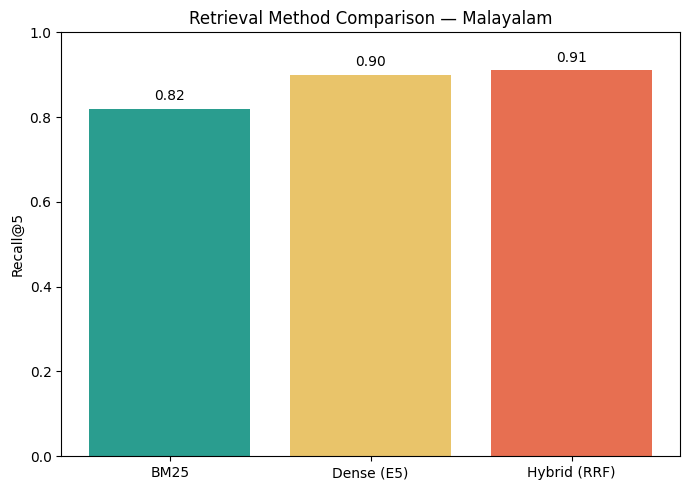

Saved: results/retrieval_comparison_chart_ml.png


In [ ]:
methods = ["BM25", "Dense (E5)", "Hybrid (RRF)"]
recall5_ml = [
    recall_at_k(questions_ml, bm25_results_ml,   5),
    recall_at_k(questions_ml, dense_results_ml,  5),
    recall_at_k(questions_ml, hybrid_results_ml, 5),
]

plt.figure(figsize=(7, 5))
plt.bar(methods, recall5_ml, color=["#2a9d8f", "#e9c46a", "#e76f51"])
plt.ylabel("Recall@5")
plt.title("Retrieval Method Comparison — Malayalam")
plt.ylim(0, 1)

for i, v in enumerate(recall5_ml):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig("results/retrieval_comparison_chart_ml.png", dpi=300)
plt.show()

print("Saved: results/retrieval_comparison_chart_ml.png")

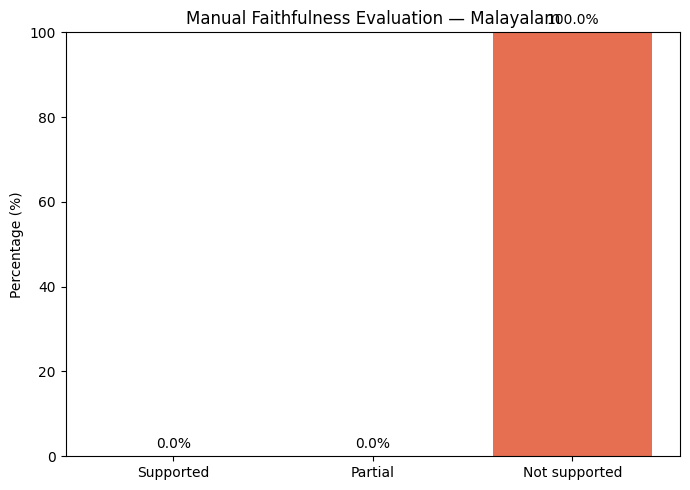

Saved: results/faithfulness_chart_ml.png


In [ ]:
faith_labels = ["Supported", "Partial", "Not supported"]
faith_values = [supported_pct, partial_pct, not_supp_pct]

plt.figure(figsize=(7, 5))
plt.bar(faith_labels, faith_values, color=["#2a9d8f", "#e9c46a", "#e76f51"])
plt.ylabel("Percentage (%)")
plt.title("Manual Faithfulness Evaluation — Malayalam")
plt.ylim(0, 100)

for i, v in enumerate(faith_values):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.savefig("results/faithfulness_chart_ml.png", dpi=300)
plt.show()

print("Saved: results/faithfulness_chart_ml.png")

## 9. Write summary markdown

In [ ]:
r1_bm25   = recall_at_k(questions_ml, bm25_results_ml,   1)
r3_bm25   = recall_at_k(questions_ml, bm25_results_ml,   3)
r5_bm25   = recall_at_k(questions_ml, bm25_results_ml,   5)
r10_bm25  = recall_at_k(questions_ml, bm25_results_ml,  10)

r1_dense  = recall_at_k(questions_ml, dense_results_ml,  1)
r3_dense  = recall_at_k(questions_ml, dense_results_ml,  3)
r5_dense  = recall_at_k(questions_ml, dense_results_ml,  5)
r10_dense = recall_at_k(questions_ml, dense_results_ml, 10)

r1_hybrid  = recall_at_k(questions_ml, hybrid_results_ml,  1)
r3_hybrid  = recall_at_k(questions_ml, hybrid_results_ml,  3)
r5_hybrid  = recall_at_k(questions_ml, hybrid_results_ml,  5)
r10_hybrid = recall_at_k(questions_ml, hybrid_results_ml, 10)

summary_text_ml = f"""
# Malayalam Phase 1 — Experiment Summary

## 1. Retrieval Comparison

We evaluated BM25, multilingual dense retrieval (multilingual-e5-base), and Hybrid RRF
on the 100-question Malayalam evaluation set (IndicWiki corpus, 247 passages).

| Metric     | BM25   | Dense (E5) | Hybrid (RRF) |
|------------|--------|------------|---------------|
| Recall@1   | {r1_bm25:.2f}   | {r1_dense:.2f}       | {r1_hybrid:.2f}          |
| Recall@3   | {r3_bm25:.2f}   | {r3_dense:.2f}       | {r3_hybrid:.2f}          |
| Recall@5   | {r5_bm25:.2f}   | {r5_dense:.2f}       | {r5_hybrid:.2f}          |
| Recall@10  | {r10_bm25:.2f}  | {r10_dense:.2f}      | {r10_hybrid:.2f}         |
| MRR        | {bm25_mrr_ml:.4f} | {dense_mrr_ml:.4f}   | {hybrid_mrr_ml:.4f}      |

## 2. Generation and Gold-Passage Ceiling

Model: Qwen/Qwen2.5-1.5B-Instruct. Malayalam-language instruction prompt.

| Condition         | EM     | F1     | Contains-match |
|-------------------|--------|--------|----------------|
| Hybrid retrieval  | {em_hybrid_ml:.4f} | {f1_hybrid_ml:.4f} | {contains_ml:.4f}       |

Refusals: {refusals_ml} / 100

## 3. Manual Faithfulness Evaluation (30 sampled)

| Label         | Count | % |
|---------------|-------|---|
| Supported     | {faithfulness_counts_ml.get('supported', 0)}    | {supported_pct}% |
| Not supported | {faithfulness_counts_ml.get('not_supported', 0)}    | {not_supp_pct}% |
| Partial       | {faithfulness_counts_ml.get('partial', 0)}    | {partial_pct}% |
| Refused       | {faithfulness_counts_ml.get('refused', 0)}    | {refused_pct}% |

Error types: {dict(error_counts_ml)}

## 4. Comparison with English Baseline

| Metric          | English | Malayalam | Drop  |
|-----------------|---------|-----------|-------|
| BM25 Recall@5   | 0.91    | {r5_bm25:.2f}      | {(0.91 - r5_bm25)*100:.0f}pp  |
| Dense Recall@5  | 0.95    | {r5_dense:.2f}      | {(0.95 - r5_dense)*100:.0f}pp  |
| Hybrid Recall@5 | 0.95    | {r5_hybrid:.2f}      | {(0.95 - r5_hybrid)*100:.0f}pp  |
| Hybrid MRR      | 0.892   | {hybrid_mrr_ml:.3f}      | {(0.892 - hybrid_mrr_ml)*100:.1f}pp  |
| Generation EM   | 0.61    | {em_hybrid_ml:.2f}      | {(0.61 - em_hybrid_ml)*100:.0f}pp  |
| Faithfulness %  | 56.7%   | {supported_pct}%      | -     |

"""

import os
os.makedirs("notes", exist_ok=True)

with open("notes/summary_ml.md", "w", encoding="utf-8") as f:
    f.write(summary_text_ml)

print("Saved: notes/summary_ml.md")
print(summary_text_ml)

Saved: notes/summary_ml.md

# Malayalam Phase 1 — Experiment Summary

## 1. Retrieval Comparison

We evaluated BM25, multilingual dense retrieval (multilingual-e5-base), and Hybrid RRF
on the 100-question Malayalam evaluation set (IndicWiki corpus, 247 passages).

| Metric     | BM25   | Dense (E5) | Hybrid (RRF) |
|------------|--------|------------|---------------|
| Recall@1   | 0.65   | 0.66       | 0.68          |
| Recall@3   | 0.75   | 0.84       | 0.87          |
| Recall@5   | 0.82   | 0.90       | 0.91          |
| Recall@10  | 0.89  | 0.93      | 0.97         |
| MRR        | 0.7152 | 0.7567   | 0.7832      |

## 2. Generation and Gold-Passage Ceiling

Model: Qwen/Qwen2.5-1.5B-Instruct. Malayalam-language instruction prompt.

| Condition         | EM     | F1     | Contains-match |
|-------------------|--------|--------|----------------|
| Hybrid retrieval  | 0.0000 | 0.0000 | 0.0000       |

Refusals: 0 / 100

## 3. Manual Faithfulness Evaluation (30 sampled)

| Label      

## 10. Push everything to GitHub

In [ ]:
!git config --global user.email "nehnamehranmk17@gmail.com"
!git config --global user.name "nehnamehrankmk638-dev"

In [ ]:
!git add results/master_summary_ml.csv \
          results/retrieval_comparison_chart_ml.png \
          results/faithfulness_chart_ml.png \
          notes/summary_ml.md

!git status

On branch nehna
Your branch is up to date with 'origin/nehna'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   notes/summary_ml.md
	new file:   results/faithfulness_chart_ml.png
	new file:   results/master_summary_ml.csv
	new file:   results/retrieval_comparison_chart_ml.png



In [ ]:
!git commit -m "ml phase1: complete summary, charts, master_summary_ml.csv"
!git push

[nehna e054231] ml phase1: complete summary, charts, master_summary_ml.csv
 4 files changed, 62 insertions(+)
 create mode 100644 notes/summary_ml.md
 create mode 100644 results/faithfulness_chart_ml.png
 create mode 100644 results/master_summary_ml.csv
 create mode 100644 results/retrieval_comparison_chart_ml.png
Enumerating objects: 11, done.
Counting objects: 100% (11/11), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (8/8), 110.16 KiB | 12.24 MiB/s, done.
Total 8 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/nehnamehranmk638-dev/multilingual-rag-research.git
   6734a42..e054231  nehna -> nehna


## ✅ Malayalam Phase 1 Complete!

All results have been saved and pushed. You can now:
- Move to **Tamil Phase 1** (`ta_01_dataset.ipynb` → `ta_07_summary.ipynb`)
- Then **Telugu Phase 1**
- Then start **Phase 2** (NLI hallucination detection) with all 3 baselines ready